# Session 8: Calibrating MMM with Experimental Results

In Session 7 we ran geo-lift experiments and measured causal effects using
synthetic control and CausalImpact. The natural next step is to **feed those
experiment results back into the MMM** as informative priors — closing the loop
between experimentation and modeling.

This session covers:

1. **Why calibrate?** — The role of priors in Bayesian MMM
2. **The PriorDistribution API** — Meridian's full prior specification system
3. **Setting ROI priors from experiments** — Using `lognormal_dist_from_mean_std` and `lognormal_dist_from_range`
4. **Per-channel priors** — Different priors for different channels
5. **ROI calibration periods** — Aligning experiment timing with model data
6. **Comparing calibrated vs uncalibrated models** — Measuring the impact

**Prerequisites:** Familiarity with Meridian model fitting (Session 5),
post-modeling diagnostics (Notebook 6), and experimentation / geo-lift
testing (Session 7).

**Reference:**
- [Set custom priors from experiments](https://developers.google.com/meridian/docs/advanced-modeling/set-custom-priors-past-experiments)
- [Configure model & ROI calibration](https://developers.google.com/meridian/docs/user-guide/configure-model)

---
## 1. Why Calibrate Priors?

### The Problem with Default Priors

Meridian's default ROI prior is `LogNormal(0.2, 0.9)` for all channels. This is
intentionally **vague** — it says "we think ROI is positive but we're not sure
how large." The result:

- Channels with noisy data may get unrealistic ROI estimates
- The model relies heavily on correlations, which can confuse causation
- Different model runs may disagree on channel rankings

### The Solution: Experimental Calibration

If you've run a **geo-experiment**, **conversion lift study**, or **A/B test**
for a channel, you have a causal estimate of its incremental impact. Encoding
this as an informative prior:

- **Anchors** the model's ROI estimate near the experimental result
- **Reduces uncertainty** for the calibrated channel
- **Improves estimates for other channels** by constraining the model
- **Resolves identifiability issues** when channels are correlated

### How Tight Should the Prior Be?

The standard deviation of your prior reflects your **confidence** in the
experiment's applicability to the MMM context:

| Confidence | Prior std | When to use |
|-----------|-----------|-------------|
| High | 0.1-0.3 | Clean geo-experiment, same time window, same population |
| Medium | 0.3-0.7 | Good experiment but different time period or audience |
| Low | 0.7-1.0+ | Rough estimate, industry benchmark, or extrapolated result |

### Caveats

Experiment results don't always map cleanly to MMM priors:

- **Timing mismatch**: The experiment may cover a different period than the MMM data
- **Estimand differences**: Experiments often measure "reduce spend by X%" vs MMM's "zero spend" counterfactual
- **Carryover effects**: Short experiments may miss long-term adstock effects
- **Population differences**: Experiment geos may not represent the full market

In [1]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from meridian.data.input_data import InputData
from meridian.model import model as meridian_model
from meridian.model import spec as meridian_spec
from meridian.model import prior_distribution
from meridian.analysis.analyzer import Analyzer
from meridian.analysis import visualizer
import meridian
from meridian import constants
import xarray as xr
import tensorflow_probability as tfp

tfd = tfp.distributions
print(f"Meridian version: {meridian.__version__}")

Meridian version: 1.4.0


In [2]:
# --- Load and prepare data (same setup as Session 5) ---
df = pd.read_excel('../../data/MMM_Workshop_Data.xlsx', sheet_name='Data')

date_col = 'Month'
kpi_col = 'Sales_Revenue_Total'

media_cols = [col for col in df.columns if 'Spend' in col or 'spend' in col]
drop_cols = ['Meta_Spends_Agg']
media_cols = [c for c in media_cols if c not in drop_cols]

n_times = len(df)
n_geos = 1
n_media = len(media_cols)

media_spend_array = df[media_cols].values.reshape(n_geos, n_times, n_media)
media_volume_array = media_spend_array.copy()
kpi_array = df[kpi_col].values.reshape(n_geos, n_times)

time_coords = [d.strftime('%Y-%m-%d') for d in pd.to_datetime(df[date_col])]
geo_coords = ['national']

input_data = InputData(
    kpi=xr.DataArray(
        kpi_array, name='kpi',
        dims=['geo', 'time'],
        coords={'time': time_coords, 'geo': geo_coords}
    ),
    kpi_type='revenue',
    population=xr.DataArray(
        [1.0], name='population',
        dims=['geo'],
        coords={'geo': geo_coords}
    ),
    media_spend=xr.DataArray(
        media_spend_array, name='media_spend',
        dims=['geo', 'time', 'media_channel'],
        coords={'time': time_coords, 'geo': geo_coords, 'media_channel': media_cols}
    ),
    media=xr.DataArray(
        media_volume_array, name='media',
        dims=['geo', 'media_time', 'media_channel'],
        coords={'media_time': time_coords, 'geo': geo_coords, 'media_channel': media_cols}
    ),
)

print(f"Dataset: {n_times} periods, {n_media} channels")
print(f"Channels: {media_cols}")

Dataset: 36 periods, 15 channels
Channels: ['TV_Spends', 'Radio_Spends', 'Outdoor_Spends', 'Paid_Search_Spends', 'Programmatic_Display_Spends', 'Google_Display_Spend', 'Direct_Display_Spend', 'Meta1_Spends', 'Programmatic_Video_Spends', 'Youtube_Spends', 'Meta2_Spends', 'Influencer_Marketing_Spends', 'Brand_B_ATL_Spends', 'Brand_PH_ATL_Spends', 'Brand_P_ATL_Spends']


---
## 2. The PriorDistribution API

Meridian's `PriorDistribution` dataclass controls priors for every model
parameter. The most important fields for calibration:

| Field | Default | What it controls |
|-------|---------|------------------|
| `roi_m` | `LogNormal(0.2, 0.9)` | ROI prior for media channels (used when `media_prior_type='roi'`) |
| `beta_m` | `HalfNormal(5.0)` | Media effect coefficients (used when `media_prior_type='coefficient'`) |
| `alpha_m` | `Uniform(0.0, 1.0)` | Adstock decay rate |
| `ec_m` | `TruncatedNormal(0.8, 0.8, 0.1, 10)` | Hill half-saturation point |
| `slope_m` | `Deterministic(1.0)` | Hill slope |
| `sigma` | `HalfNormal(5.0)` | Noise standard deviation |

### Prior Types

Meridian supports three `media_prior_type` options in `ModelSpec`:

- **`'roi'`** (default) — Prior is on ROI directly. Best for calibration.
- **`'mroi'`** — Prior is on marginal ROI. Useful when you have mROI estimates.
- **`'coefficient'`** — Prior is on the raw beta coefficients. More flexible but
  harder to calibrate from experiments.

### Scalar vs Per-Channel Priors

Each prior field accepts either:
- A **scalar** distribution → applied to all channels
- A **vector** distribution (one value per channel) → channel-specific priors

In [3]:
# --- Explore Default Priors ---
default_prior = prior_distribution.PriorDistribution()

print("=== Default Prior Settings ===")
print(f"ROI (roi_m):      {default_prior.roi_m}")
print(f"Beta (beta_m):    {default_prior.beta_m}")
print(f"Adstock (alpha_m):{default_prior.alpha_m}")
print(f"Hill EC (ec_m):   {default_prior.ec_m}")
print(f"Hill slope:       {default_prior.slope_m}")
print(f"Sigma:            {default_prior.sigma}")

=== Default Prior Settings ===
ROI (roi_m):      tfp.distributions.LogNormal("roi_m", batch_shape=[], event_shape=[], dtype=float32)
Beta (beta_m):    tfp.distributions.HalfNormal("beta_m", batch_shape=[], event_shape=[], dtype=float32)
Adstock (alpha_m):tfp.distributions.Uniform("alpha_m", batch_shape=[], event_shape=[], dtype=float32)
Hill EC (ec_m):   tfp.distributions.TruncatedNormal("ec_m", batch_shape=[], event_shape=[], dtype=float32)
Hill slope:       tfp.distributions.Deterministic("slope_m", batch_shape=[], event_shape=[], dtype=float32)
Sigma:            tfp.distributions.HalfNormal("sigma", batch_shape=[], event_shape=[], dtype=float32)


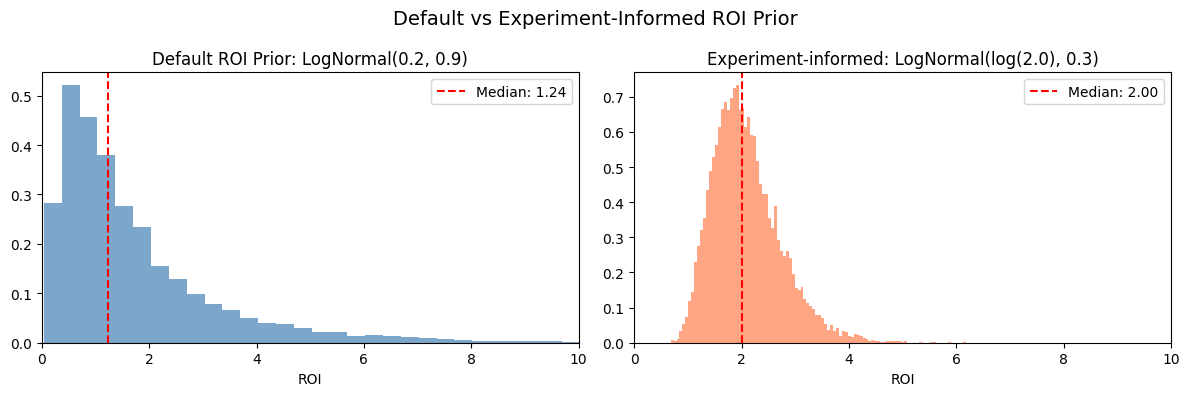

Default prior: mean=1.83, std=1.98, 95% CI=[0.21, 6.98]
Tight prior:   mean=2.09, std=0.64, 95% CI=[1.12, 3.58]


In [4]:
# --- Visualize the default ROI prior ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Default LogNormal(0.2, 0.9)
default_samples = default_prior.roi_m.sample(10000).numpy()
axes[0].hist(default_samples, bins=100, density=True, alpha=0.7, color='steelblue')
axes[0].set_title('Default ROI Prior: LogNormal(0.2, 0.9)')
axes[0].set_xlabel('ROI')
axes[0].set_xlim(0, 10)
axes[0].axvline(np.median(default_samples), color='red', linestyle='--',
                label=f'Median: {np.median(default_samples):.2f}')
axes[0].legend()

# Show what a tighter prior looks like
tight = tfd.LogNormal(np.log(2.0), 0.3)
tight_samples = tight.sample(10000).numpy()
axes[1].hist(tight_samples, bins=100, density=True, alpha=0.7, color='coral')
axes[1].set_title('Experiment-informed: LogNormal(log(2.0), 0.3)')
axes[1].set_xlabel('ROI')
axes[1].set_xlim(0, 10)
axes[1].axvline(np.median(tight_samples), color='red', linestyle='--',
                label=f'Median: {np.median(tight_samples):.2f}')
axes[1].legend()

plt.suptitle('Default vs Experiment-Informed ROI Prior', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Default prior: mean={np.mean(default_samples):.2f}, "
      f"std={np.std(default_samples):.2f}, "
      f"95% CI=[{np.percentile(default_samples, 2.5):.2f}, "
      f"{np.percentile(default_samples, 97.5):.2f}]")
print(f"Tight prior:   mean={np.mean(tight_samples):.2f}, "
      f"std={np.std(tight_samples):.2f}, "
      f"95% CI=[{np.percentile(tight_samples, 2.5):.2f}, "
      f"{np.percentile(tight_samples, 97.5):.2f}]")

---
## 3. Setting ROI Priors from Experiments

Meridian provides two helper functions to construct LogNormal priors from
experiment results:

### Option A: From Mean and Standard Deviation

Use when your experiment gives you a **point estimate** and **standard error**:

```python
lognormal_dist_from_mean_std(mean=2.0, std=0.5)
```

### Option B: From Confidence Interval

Use when your experiment gives you a **range** (e.g., "ROI is between 1.2 and 3.5
with 95% confidence"):

```python
lognormal_dist_from_range(low=1.2, high=3.5, mass_percent=0.95)
```

Both return a `tfp.distributions.LogNormal` object ready to use as `roi_m`.

Prior from mean/std:
  Mean: 1.51
  Std:  0.41
  95% CI: [0.87, 2.43]


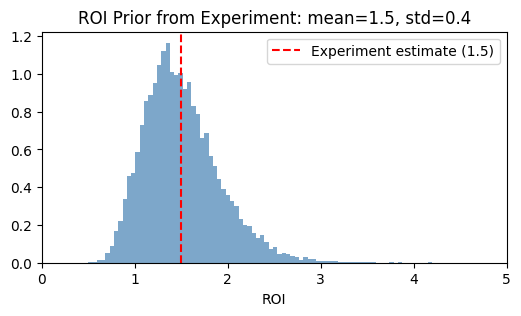

In [5]:
# --- Helper Function: From Mean and Std ---
#
# Scenario: A geo-experiment for TV measured ROI = 1.5 with SE = 0.4

roi_from_experiment = prior_distribution.lognormal_dist_from_mean_std(
    mean=1.5, std=0.4
)

samples = roi_from_experiment.sample(10000).numpy()
print(f"Prior from mean/std:")
print(f"  Mean: {np.mean(samples):.2f}")
print(f"  Std:  {np.std(samples):.2f}")
print(f"  95% CI: [{np.percentile(samples, 2.5):.2f}, {np.percentile(samples, 97.5):.2f}]")

plt.figure(figsize=(6, 3))
plt.hist(samples, bins=80, density=True, alpha=0.7, color='steelblue')
plt.axvline(1.5, color='red', linestyle='--', label='Experiment estimate (1.5)')
plt.title('ROI Prior from Experiment: mean=1.5, std=0.4')
plt.xlabel('ROI')
plt.legend()
plt.xlim(0, 5)
plt.show()

Prior from CI range:
  Mean: 2.14
  Std:  0.79
  95% CI: [1.01, 4.06]


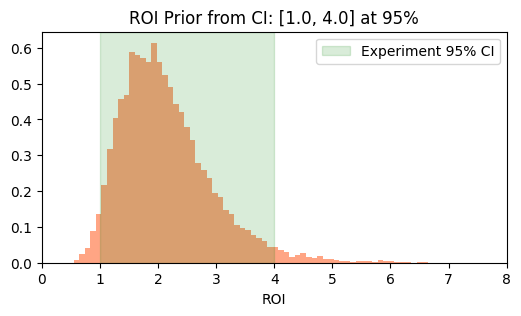

In [6]:
# --- Helper Function: From Confidence Interval ---
#
# Scenario: A lift study for Paid Search reports ROI between 1.0 and 4.0
# with 95% confidence

roi_from_ci = prior_distribution.lognormal_dist_from_range(
    low=1.0, high=4.0, mass_percent=0.95
)

samples_ci = roi_from_ci.sample(10000).numpy()
print(f"Prior from CI range:")
print(f"  Mean: {np.mean(samples_ci):.2f}")
print(f"  Std:  {np.std(samples_ci):.2f}")
print(f"  95% CI: [{np.percentile(samples_ci, 2.5):.2f}, {np.percentile(samples_ci, 97.5):.2f}]")

plt.figure(figsize=(6, 3))
plt.hist(samples_ci, bins=80, density=True, alpha=0.7, color='coral')
plt.axvspan(1.0, 4.0, alpha=0.15, color='green', label='Experiment 95% CI')
plt.title('ROI Prior from CI: [1.0, 4.0] at 95%')
plt.xlabel('ROI')
plt.legend()
plt.xlim(0, 8)
plt.show()

---
## 4. Per-Channel Priors

In practice, you won't have experiment results for every channel. Meridian
lets you set **per-channel priors** using the `get_paid_media_channels_argument_builder()`
helper, which ensures correct channel ordering.

### Typical Workflow

1. Set informative priors for channels **with experiment data**
2. Use the default (vague) prior for channels **without experiments**
3. The model combines both — experiment-informed channels anchor the model,
   which indirectly improves estimates for uncalibrated channels

In [7]:
# --- Per-Channel ROI Priors ---
#
# Simulated experiment results:
#   TV: geo-experiment → ROI = 1.3, SE = 0.3  (high confidence)
#   Paid Search: lift study → ROI = 2.0, SE = 0.8  (medium confidence)
#   Meta1: conversion lift → ROI between 1.5 and 4.0 (95% CI)
#   All others: no experiment data → use default

# Build per-channel (mu, sigma) tuples for LogNormal
# For channels without experiments, use default: (0.2, 0.9)
default_mu, default_sigma = 0.2, 0.9

# Use the helper functions to get the LogNormal parameters
# lognormal_dist_from_mean_std returns a distribution; we need mu/sigma
# for the per-channel vector approach

# Approach: Build mu and sigma arrays, one value per channel
experiment_results = {
    'TV_Spends': {'mean': 1.3, 'std': 0.3},
    'Paid_Search_Spends': {'mean': 2.0, 'std': 0.8},
    'Meta1_Spends': {'mean': 2.5, 'std': 0.6},
}

roi_mu_list = []
roi_sigma_list = []

for ch in media_cols:
    if ch in experiment_results:
        exp = experiment_results[ch]
        # Convert mean/std to LogNormal mu/sigma parameters
        # LogNormal(mu, sigma) has mean = exp(mu + sigma^2/2)
        # and variance = (exp(sigma^2) - 1) * exp(2*mu + sigma^2)
        dist = prior_distribution.lognormal_dist_from_mean_std(
            mean=exp['mean'], std=exp['std']
        )
        # Extract the underlying mu and sigma from the distribution
        mu = float(dist.loc.numpy())
        sigma = float(dist.scale.numpy())
        roi_mu_list.append(mu)
        roi_sigma_list.append(sigma)
        print(f"  {ch}: Experiment-informed → LogNormal(mu={mu:.3f}, sigma={sigma:.3f}) "
              f"[ROI mean={exp['mean']}, std={exp['std']}]")
    else:
        roi_mu_list.append(default_mu)
        roi_sigma_list.append(default_sigma)

print(f"\n{len(experiment_results)} of {n_media} channels have experiment-informed priors.")
print(f"Remaining {n_media - len(experiment_results)} channels use default LogNormal(0.2, 0.9).")

  TV_Spends: Experiment-informed → LogNormal(mu=0.236, sigma=0.228) [ROI mean=1.3, std=0.3]
  Paid_Search_Spends: Experiment-informed → LogNormal(mu=0.619, sigma=0.385) [ROI mean=2.0, std=0.8]
  Meta1_Spends: Experiment-informed → LogNormal(mu=0.888, sigma=0.237) [ROI mean=2.5, std=0.6]

3 of 15 channels have experiment-informed priors.
Remaining 12 channels use default LogNormal(0.2, 0.9).


In [8]:
# --- Create the calibrated PriorDistribution ---
calibrated_prior = prior_distribution.PriorDistribution(
    roi_m=tfd.LogNormal(
        loc=roi_mu_list,
        scale=roi_sigma_list,
        name=constants.ROI_M,
    )
)

print("Calibrated PriorDistribution created.")
print(f"ROI prior shape: {calibrated_prior.roi_m.batch_shape}")

Calibrated PriorDistribution created.
ROI prior shape: (15,)


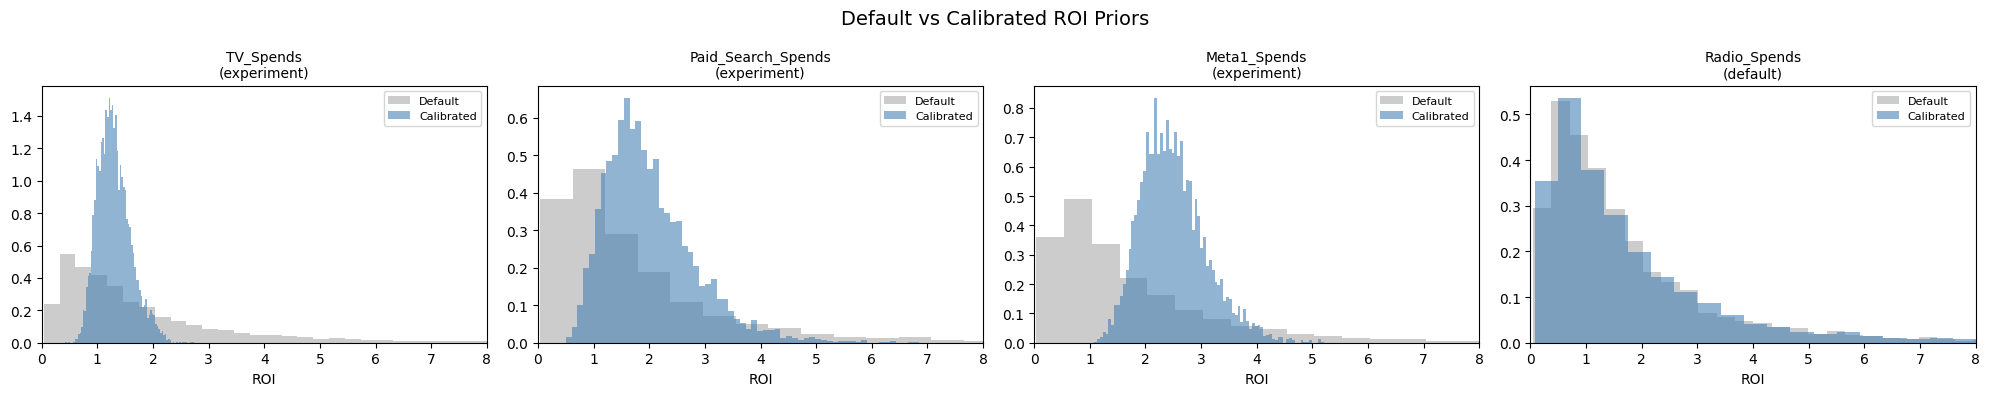

In [9]:
# --- Visualize: Default vs Calibrated Priors for Key Channels ---
channels_to_plot = ['TV_Spends', 'Paid_Search_Spends', 'Meta1_Spends', 'Radio_Spends']
fig, axes = plt.subplots(1, len(channels_to_plot), figsize=(5 * len(channels_to_plot), 4))

for ax, ch in zip(axes, channels_to_plot):
    idx = media_cols.index(ch)

    # Default prior samples
    default_dist = tfd.LogNormal(0.2, 0.9)
    default_s = default_dist.sample(5000).numpy()
    ax.hist(default_s, bins=80, density=True, alpha=0.4, color='gray', label='Default')

    # Calibrated prior samples
    calib_dist = tfd.LogNormal(roi_mu_list[idx], roi_sigma_list[idx])
    calib_s = calib_dist.sample(5000).numpy()
    ax.hist(calib_s, bins=80, density=True, alpha=0.6, color='steelblue', label='Calibrated')

    is_calibrated = ch in experiment_results
    ax.set_title(f"{ch}\n{'(experiment)' if is_calibrated else '(default)'}", fontsize=10)
    ax.set_xlabel('ROI')
    ax.set_xlim(0, 8)
    ax.legend(fontsize=8)

plt.suptitle('Default vs Calibrated ROI Priors', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. ROI Calibration Periods

When your experiment only covers a **specific time window**, you should tell
Meridian to apply the ROI prior only during that period. This is done via the
`roi_calibration_period` parameter in `ModelSpec`.

### Why This Matters

- Experiments often cover a few weeks, but the MMM spans years
- ROI can vary over time (seasonality, market changes)
- Applying an experiment prior to the full time range may distort results
  outside the experiment window

### How It Works

`roi_calibration_period` is a binary matrix of shape `(n_times, n_media_channels)`:
- `1` = apply the ROI prior during this time period for this channel
- `0` = don't constrain this period

For channels **without** experiments, set all time periods to `1` (default behavior).

In [10]:
# --- Define Experiment Time Windows ---
#
# Simulated experiment periods (matching dates in our data):
#   TV: experiment ran Nov-Dec 2021 (4 months into data)
#   Paid Search: experiment ran Mar-Apr 2022
#   Meta1: experiment ran Jun-Aug 2022

experiment_periods = {
    'TV_Spends': ['2021-11-01', '2021-12-01'],
    'Paid_Search_Spends': ['2022-03-01', '2022-04-01'],
    'Meta1_Spends': ['2022-06-01', '2022-07-01', '2022-08-01'],
}

# Build the calibration period matrix
roi_calibration_period = np.zeros((n_times, n_media))

for ch, periods in experiment_periods.items():
    ch_idx = media_cols.index(ch)
    time_mask = np.isin(time_coords, periods)
    roi_calibration_period[time_mask, ch_idx] = 1
    n_periods = time_mask.sum()
    print(f"{ch}: {n_periods} periods marked for calibration")

# For channels without experiments, set all periods to 1 (default behavior)
uncalibrated_mask = ~np.isin(media_cols, list(experiment_periods.keys()))
roi_calibration_period[:, uncalibrated_mask] = 1

print(f"\nCalibration matrix shape: {roi_calibration_period.shape}")
print(f"Non-zero entries: {int(roi_calibration_period.sum())} "
      f"out of {roi_calibration_period.size}")

TV_Spends: 2 periods marked for calibration
Paid_Search_Spends: 2 periods marked for calibration
Meta1_Spends: 3 periods marked for calibration

Calibration matrix shape: (36, 15)
Non-zero entries: 439 out of 540


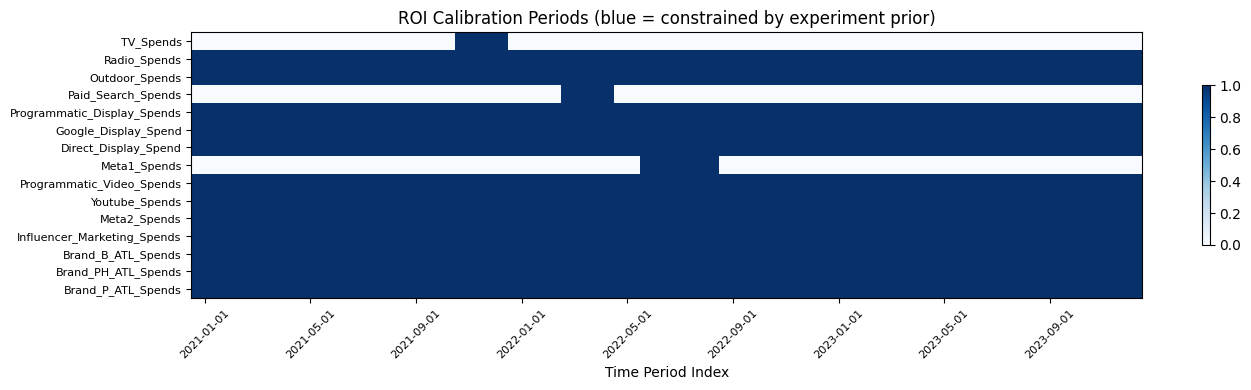

In [11]:
# --- Visualize the calibration period matrix ---
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(roi_calibration_period.T, aspect='auto', cmap='Blues',
               interpolation='nearest')
ax.set_yticks(range(n_media))
ax.set_yticklabels(media_cols, fontsize=8)
ax.set_xlabel('Time Period Index')
ax.set_title('ROI Calibration Periods (blue = constrained by experiment prior)')

# Add time labels for a few ticks
tick_positions = list(range(0, n_times, max(1, n_times // 8)))
ax.set_xticks(tick_positions)
ax.set_xticklabels([time_coords[i] for i in tick_positions], rotation=45, fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

---
## 6. Comparing Calibrated vs Uncalibrated Models

The real test: does calibration change the model's conclusions? We'll fit two
models — one with default priors, one with experiment-informed priors — and
compare:

- ROI estimates for calibrated channels
- ROI estimates for uncalibrated channels (do they shift too?)
- Prior-posterior overlap (did the data update our beliefs?)
- Model fit quality

In [12]:
# --- Model A: Default Priors (uncalibrated) ---
print("Fitting Model A (default priors)...")
spec_default = meridian_spec.ModelSpec(max_lag=8)
mmm_default = meridian_model.Meridian(
    input_data=input_data, model_spec=spec_default
)
mmm_default.sample_posterior(
    n_chains=2, n_adapt=500, n_burnin=500, n_keep=500, seed=0
)
mmm_default.sample_prior(n_draws=500, seed=0)
print("Model A fitted.")

Fitting Model A (default priors)...


2026-03-23 15:27:21.948975: I external/local_xla/xla/service/service.cc:163] XLA service 0x319a503d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-23 15:27:21.948990: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1774279641.961967 127282873 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-23 15:27:49.917769: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-23 15:27:50.753645: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Model A fitted.


In [ ]:
# --- Model B: Experiment-Calibrated Priors ---
print("Fitting Model B (calibrated priors)...")
spec_calibrated = meridian_spec.ModelSpec(
    max_lag=8,
    prior=calibrated_prior,
    roi_calibration_period=roi_calibration_period,
)
mmm_calibrated = meridian_model.Meridian(
    input_data=input_data, model_spec=spec_calibrated
)
mmm_calibrated.sample_posterior(
    n_chains=2, n_adapt=500, n_burnin=500, n_keep=500, seed=0
)
mmm_calibrated.sample_prior(n_draws=500, seed=0)
print("Model B fitted.")

Fitting Model B (calibrated priors)...


2026-03-23 15:28:48.498809: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


In [ ]:
# --- Compare ROI Estimates ---
analyzer_default = Analyzer(mmm_default)
analyzer_calibrated = Analyzer(mmm_calibrated)

roi_default = np.array(analyzer_default.roi(use_posterior=True)).mean(axis=(0, 1))
roi_calibrated = np.array(analyzer_calibrated.roi(use_posterior=True)).mean(axis=(0, 1))

comparison = pd.DataFrame({
    'Channel': media_cols,
    'ROI (Default)': roi_default,
    'ROI (Calibrated)': roi_calibrated,
    'Difference': roi_calibrated - roi_default,
    'Has Experiment': [ch in experiment_results for ch in media_cols],
})
comparison['% Change'] = (comparison['Difference'] / comparison['ROI (Default)'] * 100).round(1)

print("=== ROI Comparison: Default vs Calibrated ===")
print(comparison.to_string(index=False))

=== ROI Comparison: Default vs Calibrated ===
                    Channel  ROI (Default)  ROI (Calibrated)  Difference  Has Experiment   % Change
                  TV_Spends       1.313657          2.240534    0.926877            True  70.599998
               Radio_Spends       1.646592          1.661170    0.014579           False   0.900000
             Outdoor_Spends       3.293092          3.318189    0.025097           False   0.800000
         Paid_Search_Spends       1.779410          4.101219    2.321809            True 130.500000
Programmatic_Display_Spends       2.002444          2.027575    0.025131           False   1.300000
       Google_Display_Spend       1.881769          1.892650    0.010881           False   0.600000
       Direct_Display_Spend       2.028432          1.967258   -0.061174           False  -3.000000
               Meta1_Spends       1.670919          4.306650    2.635731            True 157.699997
  Programmatic_Video_Spends       1.966729          1.

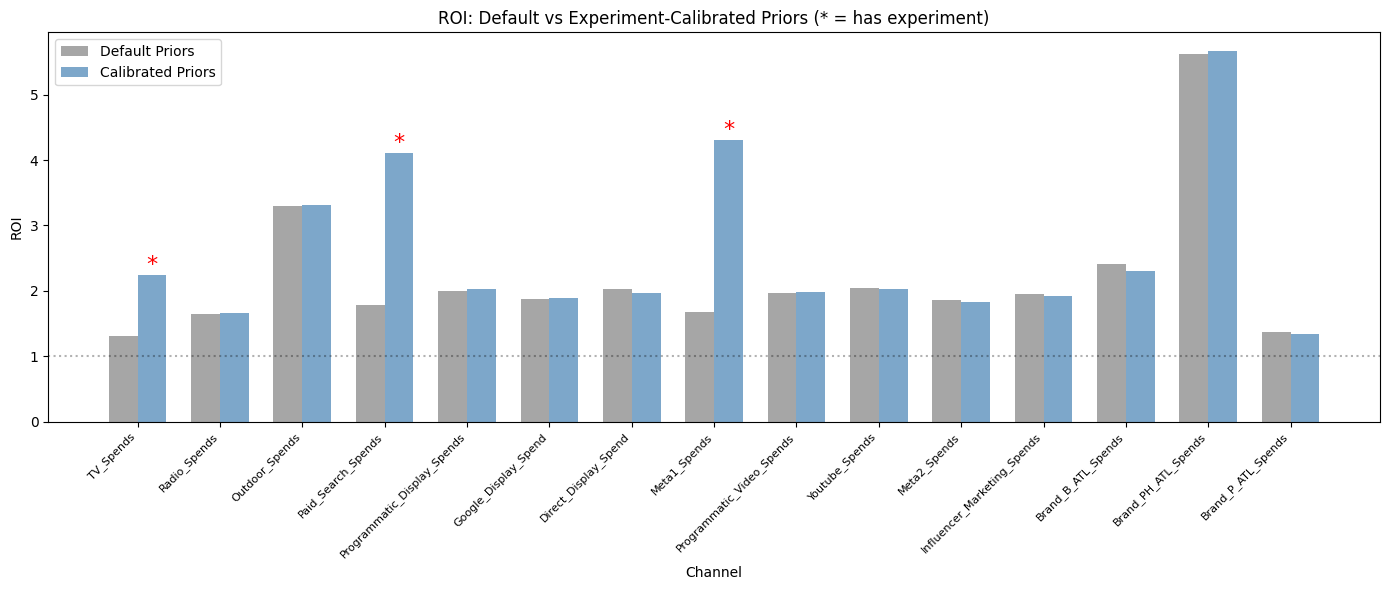

In [ ]:
# --- Visualize ROI Comparison ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(n_media)
width = 0.35

bars1 = ax.bar(x - width/2, roi_default, width, label='Default Priors',
               color='gray', alpha=0.7)
bars2 = ax.bar(x + width/2, roi_calibrated, width, label='Calibrated Priors',
               color='steelblue', alpha=0.7)

# Highlight calibrated channels
for i, ch in enumerate(media_cols):
    if ch in experiment_results:
        ax.annotate('*', (x[i] + width/2, roi_calibrated[i]),
                    ha='center', va='bottom', fontsize=16, color='red')

ax.set_xlabel('Channel')
ax.set_ylabel('ROI')
ax.set_title('ROI: Default vs Experiment-Calibrated Priors (* = has experiment)')
ax.set_xticks(x)
ax.set_xticklabels(media_cols, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.axhline(1.0, color='black', linestyle=':', alpha=0.3, label='Break-even')
plt.tight_layout()
plt.show()

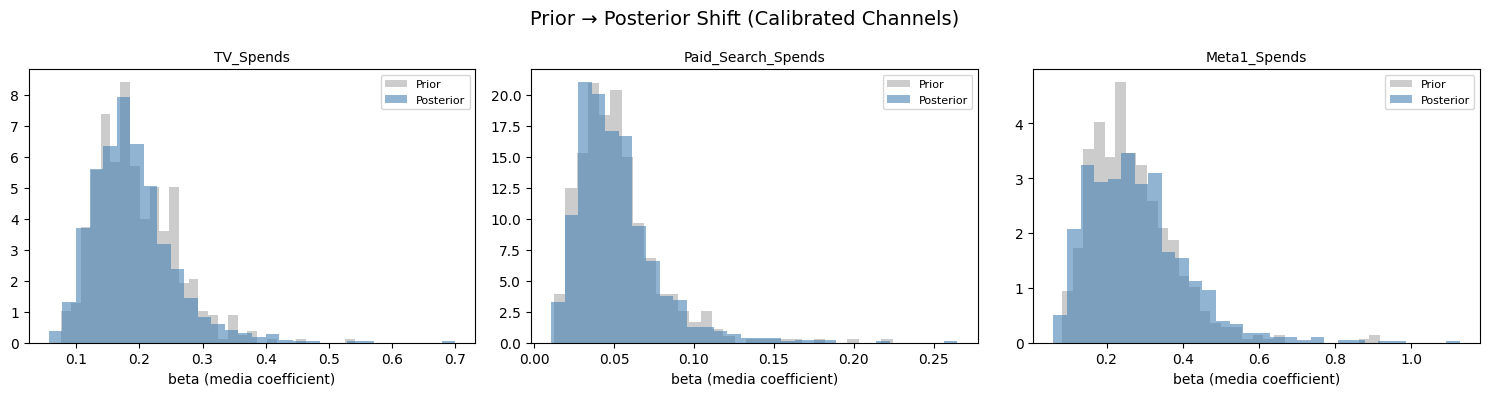

If the posterior is much narrower than the prior, the data is
informative. If the posterior matches the prior, the model is
relying heavily on the experiment-based calibration.


In [ ]:
# --- Prior vs Posterior Shift for Calibrated Channels ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, experiment_results.keys()):
    idx = media_cols.index(ch)

    # Prior (from the calibrated model)
    prior_samples = mmm_calibrated.inference_data.prior['beta_m'].isel(
        media_channel=idx
    ).values.flatten()

    # Posterior
    post_samples = mmm_calibrated.inference_data.posterior['beta_gm'].isel(
        media_channel=idx
    ).values.flatten()

    ax.hist(prior_samples, bins=30, alpha=0.4, density=True,
            color='gray', label='Prior')
    ax.hist(post_samples, bins=30, alpha=0.6, density=True,
            color='steelblue', label='Posterior')
    ax.set_title(ch, fontsize=10)
    ax.set_xlabel('beta (media coefficient)')
    ax.legend(fontsize=8)

plt.suptitle('Prior → Posterior Shift (Calibrated Channels)', fontsize=14)
plt.tight_layout()
plt.show()

print("If the posterior is much narrower than the prior, the data is")
print("informative. If the posterior matches the prior, the model is")
print("relying heavily on the experiment-based calibration.")

In [ ]:
# --- Model Fit Comparison ---
acc_default = analyzer_default.predictive_accuracy()
acc_calibrated = analyzer_calibrated.predictive_accuracy()

print("=== Predictive Accuracy ===")
print(f"\nDefault priors:")
print(acc_default)
print(f"\nCalibrated priors:")
print(acc_calibrated)

=== Predictive Accuracy ===

Default priors:
<xarray.Dataset> Size: 152B
Dimensions:          (metric: 3, geo_granularity: 1)
Coordinates:
  * metric           (metric) <U9 108B 'R_Squared' 'MAPE' 'wMAPE'
  * geo_granularity  (geo_granularity) <U8 32B 'national'
Data variables:
    value            (metric, geo_granularity) float32 12B 0.8518 ... 0.05619

Calibrated priors:
<xarray.Dataset> Size: 152B
Dimensions:          (metric: 3, geo_granularity: 1)
Coordinates:
  * metric           (metric) <U9 108B 'R_Squared' 'MAPE' 'wMAPE'
  * geo_granularity  (geo_granularity) <U8 32B 'national'
Data variables:
    value            (metric, geo_granularity) float32 12B 0.8485 0.0572 0.05652


In [ ]:
# --- Built-in Prior/Posterior Visualization (Altair) ---
# Compare using Meridian's native visualization for the calibrated model
diag = visualizer.ModelDiagnostics(mmm_calibrated)
diag.plot_prior_and_posterior_distribution(parameter='roi_m')

alt.FacetChart(...)

---
## Advanced: Customizing Other Priors

Beyond ROI, you can also calibrate:

- **Adstock decay** (`alpha_m`) — if you know a channel's effect fades within
  ~2 weeks, use a Beta prior concentrated near 0 (short memory)
- **Hill saturation** (`ec_m`) — if you know saturation kicks in at a specific
  spend level, tighten the half-saturation prior
- **Media coefficients** (`beta_m`) — if you want direct control rather than
  going through ROI (set `media_prior_type='coefficient'`)

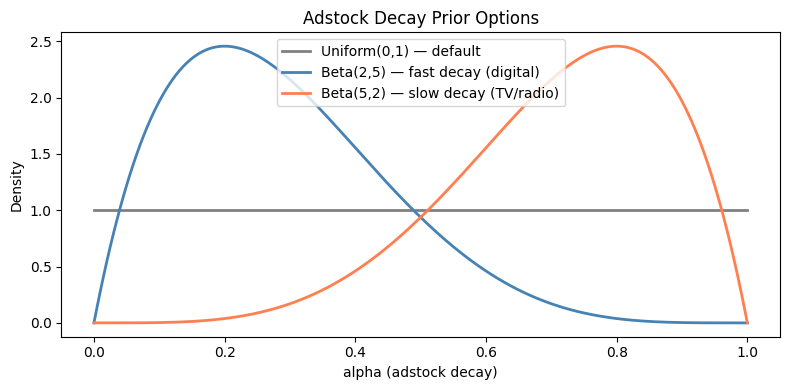

To use a custom adstock prior:
  prior = PriorDistribution(alpha_m=tfd.Beta(2.0, 5.0))
  spec = ModelSpec(prior=prior)


In [ ]:
# --- Example: Tighter Adstock Prior for Digital Channels ---
# Digital channels typically have faster decay than TV/radio.
# Default alpha_m ~ Uniform(0, 1). We can tighten for digital:

# Beta(2, 5) concentrates around 0.2-0.3 (fast decay)
# Beta(5, 2) concentrates around 0.7-0.8 (slow decay, like TV)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(0, 1, 200)

from scipy import stats

for (a, b), label, color in [
    ((1, 1), 'Uniform(0,1) — default', 'gray'),
    ((2, 5), 'Beta(2,5) — fast decay (digital)', 'steelblue'),
    ((5, 2), 'Beta(5,2) — slow decay (TV/radio)', 'coral'),
]:
    ax.plot(x, stats.beta(a, b).pdf(x), label=label, linewidth=2, color=color)

ax.set_xlabel('alpha (adstock decay)')
ax.set_ylabel('Density')
ax.set_title('Adstock Decay Prior Options')
ax.legend()
plt.tight_layout()
plt.show()

print("To use a custom adstock prior:")
print("  prior = PriorDistribution(alpha_m=tfd.Beta(2.0, 5.0))")
print("  spec = ModelSpec(prior=prior)")

---
## Exercises

1. **Sensitivity analysis**: Pick one calibrated channel and try three different
   prior strengths (std = 0.2, 0.5, 1.0). How much does the posterior ROI change?
   At what point does the prior dominate vs the data?

2. **Add a calibration period**: Take the calibrated model and restrict the
   TV experiment prior to only 2 months. Does the ROI estimate change vs
   applying it to the full time range?

3. **Conflicting evidence**: Set the TV prior to ROI = 5.0 (unrealistically
   high). How does the model handle the conflict between the prior and the data?
   Does the posterior push back?

4. **Cascade effects**: Calibrate only TV with a very tight prior. Do the ROI
   estimates for other channels change compared to the fully uncalibrated model?
   Why might this happen?

In [ ]:
# TODO: Exercise 1 — Prior sensitivity analysis
# for std_val in [0.2, 0.5, 1.0]:
#     dist = prior_distribution.lognormal_dist_from_mean_std(mean=1.3, std=std_val)
#     mu, sigma = float(dist.loc.numpy()), float(dist.scale.numpy())
#     # Rebuild per-channel priors with this std for TV
#     # Fit model, compare ROI

In [ ]:
# TODO: Exercise 2 — Calibration period effect
# Build roi_calibration_period with only 2 months for TV
# vs all periods = 1 for TV
# Compare ROI estimates

In [ ]:
# TODO: Exercise 3 — Conflicting prior
# Set TV ROI prior mean = 5.0 with tight std = 0.2
# Does the posterior converge to 5.0 or push back toward the data?

In [ ]:
# TODO: Exercise 4 — Cascade effects
# Calibrate only TV with a tight prior
# Compare all channels' ROI vs the uncalibrated model

---
## Key Takeaways

1. **Experiments are the gold standard** for causal media measurement. Using them
   to calibrate MMM priors gives you the best of both worlds: causal grounding
   from experiments + full-funnel coverage from MMM.

2. **Prior strength should match your confidence.** Don't use a tight prior
   unless you trust the experiment's applicability to the MMM context.

3. **Use `roi_calibration_period`** when experiments cover only part of the
   modeling window. This prevents the prior from distorting estimates in
   time periods where it doesn't apply.

4. **Calibrating one channel improves all channels.** By anchoring one channel's
   ROI, you reduce the model's degrees of freedom, which indirectly tightens
   estimates for correlated channels.

5. **Always compare calibrated vs uncalibrated models.** If calibration
   dramatically changes your results, investigate why — either the default
   model was wrong, or the experiment prior doesn't fit the data.